### Retrieval and Cross-Matching of Variable Stars from International Variable Star Index with DP1

Note: Can access website [here](https://vsx.aavso.org/)

In [1]:
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lsst.rsp import get_tap_service

In [2]:
service = get_tap_service('tap')

In [3]:
# start by retrieving the coordinates of all regions of interest (all dp1 captured fields), creating sky_coord objects

coord_47 = SkyCoord(6.02, -72.08, unit='deg') # 47 TUC
coord_lelf = SkyCoord(37.86, 6.98, unit='deg') # Low Ecliptic Latitude Field
coord_fornax = SkyCoord(40.00, -34.45, unit='deg') # Fornax dSph
coord_ecdfs = SkyCoord(53.13, -28.10, unit='deg') # Extended Chandra Deep Field South
coord_edfs = SkyCoord(59.10, -48.73, unit='deg') # Euclid Deep Field South
coord_lglf = SkyCoord(95.00, -25.00, unit='deg') # Low Galactic Latitude Field
coord_seaneb = SkyCoord(106.23, -10.51, unit='deg') # Seagull Nebula

Vizier.ROW_LIMIT = -1
radius = 1 * u.deg

# define lists of identifiers for each variable star (as per this catalog)
rrl_ident = ['RR', 'RRAB', 'RRC', 'RRD']
ceph_ident = ['CEP', 'DCEP', 'DCEPS', 'DCEP(B)', 'CW', 'CWA', 'CWB', 'BLHER', 'WVir', 'RVTAU']
lpv_ident = ['M', 'SR', 'SRA', 'SRB', 'SRC', 'SRD', 'L', 'LB', 'LC']

In [4]:
# query each region using Vizier for International V-Star Index
results_47 = Vizier.query_region(coord_47, radius=radius, catalog='B/vsx')
results_lelf = Vizier.query_region(coord_lelf, radius=radius, catalog='B/vsx')
results_fornax = Vizier.query_region(coord_fornax, radius=radius, catalog='B/vsx')
results_ecdfs = Vizier.query_region(coord_ecdfs, radius=radius, catalog='B/vsx')
results_edfs = Vizier.query_region(coord_edfs, radius=radius, catalog='B/vsx')
results_lglf = Vizier.query_region(coord_lglf, radius=radius, catalog='B/vsx')
results_seaneb = Vizier.query_region(coord_seaneb, radius=radius, catalog='B/vsx')

In [5]:
print(results_47.keys())
print(results_lelf.keys())
print(results_fornax.keys())
print(results_ecdfs.keys())
print(results_edfs.keys())
print(results_lglf.keys())
print(results_seaneb.keys())

['B/vsx/vsx']
['B/vsx/vsx']
['B/vsx/vsx']
['B/vsx/vsx']
['B/vsx/vsx']
['B/vsx/vsx']
['B/vsx/vsx']


In [6]:
# convert all to dfs
df_47 = results_47[0].to_pandas()
df_lelf = results_lelf[0].to_pandas()
df_fornax = results_fornax[0].to_pandas()
df_ecdfs = results_ecdfs[0].to_pandas()
df_edfs = results_edfs[0].to_pandas()
df_lglf = results_lglf[0].to_pandas()
df_seaneb = results_seaneb[0].to_pandas()


In [7]:
# print out their shape
print('47 Tuc:', df_47.shape)
print('Low Ecliptic:', df_lelf.shape)
print('Fornax:', df_fornax.shape)
print('ECDFS:', df_ecdfs.shape)
print('Low Galactic:', df_lglf.shape)
print('Seagull Nebula:', df_seaneb.shape)

47 Tuc: (775, 20)
Low Ecliptic: (50, 20)
Fornax: (334, 20)
ECDFS: (218, 20)
Low Galactic: (491, 20)
Seagull Nebula: (1140, 20)


In [8]:
# retrieve all rrl, ceph, lpv for each region and store in respective df
df_47_rrl = df_47[df_47['Type'].isin(rrl_ident)]
df_47_ceph = df_47[df_47['Type'].isin(ceph_ident)]
df_47_lpv = df_47[df_47['Type'].isin(lpv_ident)]

df_lelf_rrl = df_lelf[df_lelf['Type'].isin(rrl_ident)]
df_lelf_ceph = df_lelf[df_lelf['Type'].isin(ceph_ident)]
df_lelf_lpv = df_lelf[df_lelf['Type'].isin(lpv_ident)]

df_fornax_rrl = df_fornax[df_fornax['Type'].isin(rrl_ident)]
df_fornax_ceph = df_fornax[df_fornax['Type'].isin(ceph_ident)]
df_fornax_lpv = df_fornax[df_fornax['Type'].isin(lpv_ident)]

df_ecdfs_rrl = df_ecdfs[df_ecdfs['Type'].isin(rrl_ident)]
df_ecdfs_ceph = df_ecdfs[df_ecdfs['Type'].isin(ceph_ident)]
df_ecdfs_lpv = df_ecdfs[df_ecdfs['Type'].isin(lpv_ident)]

df_edfs_rrl = df_edfs[df_edfs['Type'].isin(rrl_ident)]
df_edfs_ceph = df_edfs[df_edfs['Type'].isin(ceph_ident)]
df_edfs_lpv = df_edfs[df_edfs['Type'].isin(lpv_ident)]

df_lglf_rrl = df_lglf[df_lglf['Type'].isin(rrl_ident)]
df_lglf_ceph = df_lglf[df_lglf['Type'].isin(ceph_ident)]
df_lglf_lpv = df_lglf[df_lglf['Type'].isin(lpv_ident)]

df_seaneb_rrl = df_seaneb[df_seaneb['Type'].isin(rrl_ident)]
df_seaneb_ceph = df_seaneb[df_seaneb['Type'].isin(ceph_ident)]
df_seaneb_lpv = df_seaneb[df_seaneb['Type'].isin(lpv_ident)]

In [9]:
print("📊 Variable Star Counts by Region and Type\n")

print(f"47 Tuc - RR Lyrae: {df_47_rrl.shape}")
print(f"47 Tuc - Cepheids: {df_47_ceph.shape}")
print(f"47 Tuc - LPVs:     {df_47_lpv.shape}\n")

print(f"Low Ecliptic Latitude Field - RR Lyrae: {df_lelf_rrl.shape}")
print(f"Low Ecliptic Latitude Field - Cepheids: {df_lelf_ceph.shape}")
print(f"Low Ecliptic Latitude Field - LPVs:     {df_lelf_lpv.shape}\n")

print(f"Fornax - RR Lyrae: {df_fornax_rrl.shape}")
print(f"Fornax - Cepheids: {df_fornax_ceph.shape}")
print(f"Fornax - LPVs:     {df_fornax_lpv.shape}\n")

print(f"ECDFS - RR Lyrae: {df_ecdfs_rrl.shape}")
print(f"ECDFS - Cepheids: {df_ecdfs_ceph.shape}")
print(f"ECDFS - LPVs:     {df_ecdfs_lpv.shape}\n")

print(f"EDFS - RR Lyrae: {df_edfs_rrl.shape}")
print(f"EDFS - Cepheids: {df_edfs_ceph.shape}")
print(f"EDFS - LPVs:     {df_edfs_lpv.shape}\n")

print(f"Low Galactic Latitude Field - RR Lyrae: {df_lglf_rrl.shape}")
print(f"Low Galactic Latitude Field - Cepheids: {df_lglf_ceph.shape}")
print(f"Low Galactic Latitude Field - LPVs:     {df_lglf_lpv.shape}\n")

print(f"Seagull Nebula - RR Lyrae: {df_seaneb_rrl.shape}")
print(f"Seagull Nebula - Cepheids: {df_seaneb_ceph.shape}")
print(f"Seagull Nebula - LPVs:     {df_seaneb_lpv.shape}")

📊 Variable Star Counts by Region and Type

47 Tuc - RR Lyrae: (296, 20)
47 Tuc - Cepheids: (15, 20)
47 Tuc - LPVs:     (99, 20)

Low Ecliptic Latitude Field - RR Lyrae: (4, 20)
Low Ecliptic Latitude Field - Cepheids: (0, 20)
Low Ecliptic Latitude Field - LPVs:     (1, 20)

Fornax - RR Lyrae: (17, 20)
Fornax - Cepheids: (1, 20)
Fornax - LPVs:     (99, 20)

ECDFS - RR Lyrae: (3, 20)
ECDFS - Cepheids: (0, 20)
ECDFS - LPVs:     (1, 20)

EDFS - RR Lyrae: (3, 20)
EDFS - Cepheids: (0, 20)
EDFS - LPVs:     (2, 20)

Low Galactic Latitude Field - RR Lyrae: (6, 20)
Low Galactic Latitude Field - Cepheids: (0, 20)
Low Galactic Latitude Field - LPVs:     (8, 20)

Seagull Nebula - RR Lyrae: (6, 20)
Seagull Nebula - Cepheids: (1, 20)
Seagull Nebula - LPVs:     (76, 20)


In [10]:
# adding column in each df for the region
df_47_rrl.loc[:, 'Region'] = '47'
df_47_ceph.loc[:, 'Region'] = '47'
df_47_lpv.loc[:, 'Region'] = '47'

df_lelf_rrl.loc[:, 'Region'] = 'LELF'
# df_lelf_ceph.loc[:, 'Region'] = 'LELF' ** EMPTY
df_lelf_lpv.loc[:, 'Region'] = 'LELF'

df_fornax_rrl.loc[:, 'Region'] = 'Fornax'
df_fornax_ceph.loc[:, 'Region'] = 'Fornax'
df_fornax_lpv.loc[:, 'Region'] = 'Fornax'

df_ecdfs_rrl.loc[:, 'Region'] = 'ECDFS'
df_ecdfs_lpv.loc[:, 'Region'] = 'ECDFS'
# df_ecdfs_ceph.loc[:, 'Region'] = 'ECDFS' ** EMPTY

df_edfs_rrl.loc[:, 'Region'] = 'EDFS'
# df_edfs_ceph.loc[:, 'Region'] = 'EDFS'
df_edfs_lpv.loc[:, 'Region'] = 'EDFS'

df_lglf_rrl.loc[:, 'Region'] = 'LGLF'
# df_lglf_ceph.loc[:, 'Region'] = 'LGLF'
df_lglf_lpv.loc[:, 'Region'] = 'LGLF'


df_seaneb_rrl.loc[:, 'Region'] = 'Seagull'
df_seaneb_ceph.loc[:, 'Region'] = 'Seagull'
df_seaneb_lpv.loc[:, 'Region'] = 'Seagull'

/tmp/ipykernel_3874/1130561808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_47_rrl.loc[:, 'Region'] = '47'
/tmp/ipykernel_3874/1130561808.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_47_ceph.loc[:, 'Region'] = '47'
/tmp/ipykernel_3874/1130561808.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [13]:
# concatenate all RRL Dataframes
df_rrl_all = pd.concat([
    df_47_rrl, df_lelf_rrl, df_fornax_rrl,
    df_ecdfs_rrl, df_edfs_rrl, df_lglf_rrl, df_seaneb_rrl
], ignore_index=True)

# Concatenate all Cepheid DataFrames
df_ceph_all = pd.concat([
    df_47_ceph, df_fornax_ceph, df_seaneb_ceph
], ignore_index=True)

# Concatenate all LPV DataFrames
df_lpv_all = pd.concat([
    df_47_lpv, df_lelf_lpv, df_fornax_lpv,
    df_ecdfs_lpv, df_edfs_lpv, df_lglf_lpv, df_seaneb_lpv
], ignore_index=True)

In [14]:
# rename coordinate columns
df_rrl_all.rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'}, inplace=True)
df_ceph_all.rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'}, inplace=True)
df_lpv_all.rename(columns={'RAJ2000': 'ra', 'DEJ2000': 'dec'}, inplace=True)

In [15]:
# double check the shape of these
print(df_rrl_all.shape)
print(df_ceph_all.shape)
print(df_lpv_all.shape)

(335, 21)
(17, 21)
(286, 21)


### Cross-Matching Coordinates with DP1 DiaObjects

In [16]:
# get all of the coordinates and convert to skycoord for matching
df_rrl_all['ra'] = pd.to_numeric(df_rrl_all['ra'], errors='coerce')
df_rrl_all['dec'] = pd.to_numeric(df_rrl_all['dec'], errors='coerce')

df_ceph_all['ra'] = pd.to_numeric(df_ceph_all['ra'], errors='coerce')
df_ceph_all['dec'] = pd.to_numeric(df_ceph_all['dec'], errors='coerce')

df_lpv_all['ra'] = pd.to_numeric(df_lpv_all['ra'], errors='coerce')
df_lpv_all['dec'] = pd.to_numeric(df_lpv_all['dec'], errors='coerce')

coords_rrl_all = SkyCoord(ra=df_rrl_all['ra'].values* u.deg, dec=df_rrl_all['dec'].values*u.deg)
coords_ceph_all = SkyCoord(ra=df_ceph_all['ra'].values * u.deg, dec=df_ceph_all['dec'].values*u.deg)
coords_lpv_all = SkyCoord(ra=df_lpv_all['ra'].values *u.deg, dec=df_lpv_all['dec'].values*u.deg)

In [17]:
# now perform dp1 diaobject query
query = """SELECT diaObjectId, ra, dec, g_psfFluxMean, r_psfFluxMean, i_psfFluxMean,
        g_psfFluxSigma, r_psfFluxSigma, i_psfFluxSigma,
        g_psfFluxChi2, r_psfFluxChi2, i_psfFluxChi2,
        g_psfFluxStetsonJ, r_psfFluxStetsonJ, i_psfFluxStetsonJ,
        g_psfFluxMAD, r_psfFluxMAD, i_psfFluxMAD,
        g_psfFluxNdata, r_psfFluxNdata, i_psfFluxNdata, nDiaSources
        FROM dp1.DiaObject
        WHERE ra IS NOT NULL
        AND dec IS NOT NULL
        """

job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
df_rsp = job.fetch_result().to_table().to_pandas() #get results -> turn into table -> turn table into pandas dataframe
print(str(len(df_rsp)))

Job phase is COMPLETED
1089818


In [18]:
# retrieve coordinates for all dp1 diaobjects we retrieved
coords_rsp = SkyCoord(ra=df_rsp['ra'].values * u.deg, dec=df_rsp['dec'].values* u.deg)

In [19]:
# perform cross matching within 1 arcsecond using same methodology as before
idx_rrl, d2d_rrl, _ = coords_rrl_all.match_to_catalog_sky(coords_rsp)
matches_rrl = d2d_rrl < 1 * u.arcsec
matched_vars_rrl = df_rrl_all[matches_rrl].reset_index(drop=True)
matched_diaObjects_rrl = df_rsp.iloc[idx_rrl[matches_rrl]].reset_index(drop=True)
# add region as column in matched diaobjects table
matched_diaObjects_rrl['Region'] = matched_vars_rrl["Region"]

idx_ceph, d2d_ceph, _ = coords_ceph_all.match_to_catalog_sky(coords_rsp)
matches_ceph = d2d_ceph < 1 * u.arcsec
matched_vars_ceph = df_ceph_all[matches_ceph].reset_index(drop=True)
matched_diaObjects_ceph = df_rsp.iloc[idx_ceph[matches_ceph]].reset_index(drop=True)
matched_diaObjects_ceph['Region'] = matched_vars_ceph["Region"]

idx_lpv, d2d_lpv, _  = coords_lpv_all.match_to_catalog_sky(coords_rsp)
matches_lpv = d2d_lpv < 1 * u.arcsec
matched_vars_lpv = df_lpv_all[matches_lpv].reset_index(drop=True)
matched_diaObjects_lpv = df_rsp.iloc[idx_lpv[matches_lpv]].reset_index(drop=True)
matched_diaObjects_lpv['Region'] = matched_vars_lpv["Region"]

In [20]:
matched_diaObjects_rrl

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region
0,579577524170785196,4.096499,-72.030659,NaN,-6098.156250,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47
1,579578211365552184,4.304549,-71.973775,NaN,-1960.062378,NaN,NaN,7169.680176,NaN,NaN,...,18.546435,NaN,NaN,5069.729980,NaN,NaN,2.0,NaN,2,47
2,579576836976017478,4.317033,-72.162021,NaN,-1832.922607,-3774.826172,NaN,6690.264918,NaN,NaN,...,11.742120,NaN,NaN,401.752014,0.000000,NaN,3.0,1.0,4,47
3,579577455451308889,4.664341,-72.066207,-1840.047119,-2714.806152,-1039.450195,NaN,471.350435,5554.205386,0.000000e+00,...,0.137160,6.813223,0.000000,84.913597,590.870972,1.0,3.0,11.0,15,47
4,579576768256541517,4.706562,-72.160786,-351.814789,3467.536133,6139.622559,7214.160997,9024.375659,5236.177736,1.624360e+03,...,16.040711,11.707720,6037.700195,4511.680176,4466.910156,4.0,3.0,4.0,11,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,592913981740417050,58.835037,-48.791213,21831.128906,-5911.098633,31229.335938,112893.138390,70134.147509,43127.776855,1.349680e+06,...,86.808303,55.280970,10411.000000,38379.500000,25812.900391,43.0,69.0,36.0,207,EDFS
76,614431011979133047,94.790826,-24.681148,1567.132080,1291.368164,183.626526,7373.947285,6639.214868,5384.510285,2.987890e+04,...,24.457161,13.449594,2969.939941,6310.859863,3541.000000,28.0,33.0,8.0,74,LGLF
77,614439120877388808,95.014305,-24.444114,NaN,1797.817017,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,LGLF
78,614436990573609020,95.124193,-25.043283,10664.968750,-103542.789062,115696.320312,236679.172789,217021.149015,169139.897988,1.741140e+06,...,148.705147,109.824706,213721.000000,115552.000000,63010.898438,50.0,55.0,19.0,190,LGLF


In [21]:
matched_diaObjects_ceph

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region
0,579576012342296929,5.474521,-72.373022,-2584.693848,-45243.054688,-57625.726562,125493.267019,94762.097552,78457.273230,237507.0,...,109.712154,82.755540,12320.900391,17794.300781,27993.000000,7.0,24.0,12.0,43,47
1,579582540692586533,7.103005,-72.476959,NaN,-74538.890625,-16331.326172,NaN,283995.259318,NaN,NaN,...,107.648640,NaN,NaN,6715.229980,0.000000,NaN,9.0,1.0,10,47
2,604063441962929170,39.862315,-34.468428,NaN,-2674.626465,-2364.029785,NaN,2562.558292,2164.559614,NaN,...,17.880405,3.507904,NaN,243.339005,96.584702,NaN,4.0,6.0,10,Fornax
3,630406778491766139,105.859294,-10.282883,-107177.359375,NaN,NaN,161462.592668,NaN,NaN,283399.0,...,NaN,NaN,69538.796875,NaN,NaN,5.0,NaN,NaN,5,Seagull


In [22]:
matched_diaObjects_lpv

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,r_psfFluxStetsonJ,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region
0,579576149781250061,4.525512,-72.403472,NaN,55002.207031,98587.835938,NaN,4811.157227,NaN,NaN,...,2.220135,NaN,NaN,3402.000000,0.000000,NaN,2.0,1.0,4,47
1,579575393867006274,4.834349,-72.527929,19967.119141,NaN,22279.712891,NaN,NaN,NaN,0.000000,...,NaN,NaN,0.000000,NaN,0.000000,1.0,NaN,1.0,2,47
2,579575393867006064,4.883300,-72.543756,13587.747070,32999.347656,6635.610840,NaN,NaN,NaN,0.000000,...,NaN,NaN,0.000000,0.000000,0.000000,1.0,1.0,1.0,3,47
3,579574637952761891,5.389880,-72.696395,NaN,NaN,18112.621094,NaN,NaN,9335.155362,NaN,...,NaN,3.329511,NaN,NaN,6600.950195,NaN,NaN,2.0,2,47
4,579574637952761936,5.723430,-72.693390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,628767750252135968,106.488667,-10.987516,-68184.242188,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,NaN,2,Seagull
137,630406503613859208,106.521993,-10.245376,538513.062500,NaN,NaN,79928.728673,NaN,NaN,7601.680176,...,NaN,NaN,33354.000000,NaN,NaN,12.0,NaN,NaN,13,Seagull
138,628769055922192627,106.622277,-10.566639,2138.692627,-1195.271362,NaN,684.783280,2387.641973,NaN,25.487000,...,3.134402,NaN,183.225006,1393.849976,NaN,7.0,11.0,NaN,21,Seagull
139,630407122089148463,106.685155,-10.139335,-35625.531250,501611.468750,NaN,22539.851146,56793.356955,NaN,1118.719971,...,17.391187,NaN,290.031006,51048.000000,NaN,3.0,3.0,NaN,6,Seagull


In [23]:
# add classification column for each star
matched_diaObjects_rrl['Class'] = 'RRLyrae'
matched_diaObjects_ceph['Class'] = 'Cepheid'
matched_diaObjects_lpv['Class'] = 'LPV'

#Combine dataframes (with new labels) into one dataframe
labeled_table = pd.concat([matched_diaObjects_rrl, matched_diaObjects_ceph, matched_diaObjects_lpv], axis=0, ignore_index=False)

In [24]:
labeled_table.shape

(225, 24)

In [25]:
labeled_table

,diaObjectId,ra,dec,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,g_psfFluxSigma,r_psfFluxSigma,i_psfFluxSigma,g_psfFluxChi2,...,i_psfFluxStetsonJ,g_psfFluxMAD,r_psfFluxMAD,i_psfFluxMAD,g_psfFluxNdata,r_psfFluxNdata,i_psfFluxNdata,nDiaSources,Region,Class
0,579577524170785196,4.096499,-72.030659,NaN,-6098.156250,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.000000,NaN,NaN,1.0,NaN,1,47,RRLyrae
1,579578211365552184,4.304549,-71.973775,NaN,-1960.062378,NaN,NaN,7169.680176,NaN,NaN,...,NaN,NaN,5069.729980,NaN,NaN,2.0,NaN,2,47,RRLyrae
2,579576836976017478,4.317033,-72.162021,NaN,-1832.922607,-3774.826172,NaN,6690.264918,NaN,NaN,...,NaN,NaN,401.752014,0.000000,NaN,3.0,1.0,4,47,RRLyrae
3,579577455451308889,4.664341,-72.066207,-1840.047119,-2714.806152,-1039.450195,NaN,471.350435,5554.205386,0.000000,...,6.813223,0.000000,84.913597,590.870972,1.0,3.0,11.0,15,47,RRLyrae
4,579576768256541517,4.706562,-72.160786,-351.814789,3467.536133,6139.622559,7214.160997,9024.375659,5236.177736,1624.359985,...,11.707720,6037.700195,4511.680176,4466.910156,4.0,3.0,4.0,11,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,628767750252135968,106.488667,-10.987516,-68184.242188,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,0.000000,NaN,NaN,1.0,NaN,NaN,2,Seagull,LPV
137,630406503613859208,106.521993,-10.245376,538513.062500,NaN,NaN,79928.728673,NaN,NaN,7601.680176,...,NaN,33354.000000,NaN,NaN,12.0,NaN,NaN,13,Seagull,LPV
138,628769055922192627,106.622277,-10.566639,2138.692627,-1195.271362,NaN,684.783280,2387.641973,NaN,25.487000,...,NaN,183.225006,1393.849976,NaN,7.0,11.0,NaN,21,Seagull,LPV
139,630407122089148463,106.685155,-10.139335,-35625.531250,501611.468750,NaN,22539.851146,56793.356955,NaN,1118.719971,...,NaN,290.031006,51048.000000,NaN,3.0,3.0,NaN,6,Seagull,LPV


In [26]:
# check counts by region
labeled_table['Region'].value_counts()

Region
Fornax     103
47          81
Seagull     31
LGLF         5
LELF         4
EDFS         1
Name: count, dtype: int64

### Investigate as to why so many 47 Tuc variable stars we originally retrieved were cut out from cross matching

In [27]:
# figure out why so many stars in 47 tuc got cut out from our query
# plot where they are located before dp1 matching

# retrieve all rrl, ceph, and lpvs from 47 Tuc region
df_rrl_all_47 = df_rrl_all[df_rrl_all['Region'] == '47']
df_ceph_all_47 = df_ceph_all[df_ceph_all['Region'] == '47']
df_lpv_all_47 = df_lpv_all[df_lpv_all['Region'] == '47']

df_rrl_all_47['Class'] = 'RRLyrae'
df_ceph_all_47['Class'] = 'Cepheid'
df_lpv_all_47['Class'] = 'LPV'

/tmp/ipykernel_121/2758183343.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rrl_all_47['Class'] = 'RRLyrae'
/tmp/ipykernel_121/2758183343.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ceph_all_47['Class'] = 'Cepheid'
/tmp/ipykernel_121/2758183343.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_gu

In [28]:
tuc_47_stars = pd.concat([df_rrl_all_47, df_ceph_all_47, df_lpv_all_47])

In [29]:
tuc_47_stars

,OID,n_OID,Name,V,Type,l_max,max,u_max,n_max,f_min,...,u_min,n_min,l_Period,Period,u_Period,Sp,ra,dec,Region,Class
0,2557356,,Gaia DR3 4689787215567739008,0,RRAB,,18.920000,,G,,...,,G,,0.564800,,,3.09406,-71.94599,47,RRLyrae
1,8700640,,Gaia DR3 4689699499449288832,0,RRC,,19.260000,,G,,...,,G,,0.322361,,,3.13235,-72.47005,47,RRLyrae
2,8700693,,Gaia DR3 4689794362393447424,0,RRC,,19.510000,,G,,...,,G,,0.313582,,,3.30720,-71.74756,47,RRLyrae
3,8700696,,Gaia DR3 4689772337801140864,0,RRAB,,19.330000,,G,,...,,G,,0.728190,,,3.31484,-72.02341,47,RRLyrae
4,2559359,,Gaia DR3 4701805019393613824,0,RR,,18.629999,,G,,...,,G,,NaN,,,3.38123,-71.66036,47,RRLyrae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,8283088,,Gaia DR3 4689969463917753984,0,L,,15.760000,,G,,...,,G,,NaN,,K,8.76828,-71.77461,47,LPV
95,2600668,,Gaia DR3 4689172867749106048,0,L,,16.090000,,G,,...,,G,,NaN,,K,8.84298,-72.42108,47,LPV
96,2601208,,Gaia DR3 4689196575968452736,0,L,,15.350000,,G,,...,,G,,NaN,,K,8.91619,-72.08570,47,LPV
97,2602733,,Gaia DR3 4689947748561769344,0,L,,16.020000,,G,,...,,G,,NaN,,K,9.11946,-72.02074,47,LPV


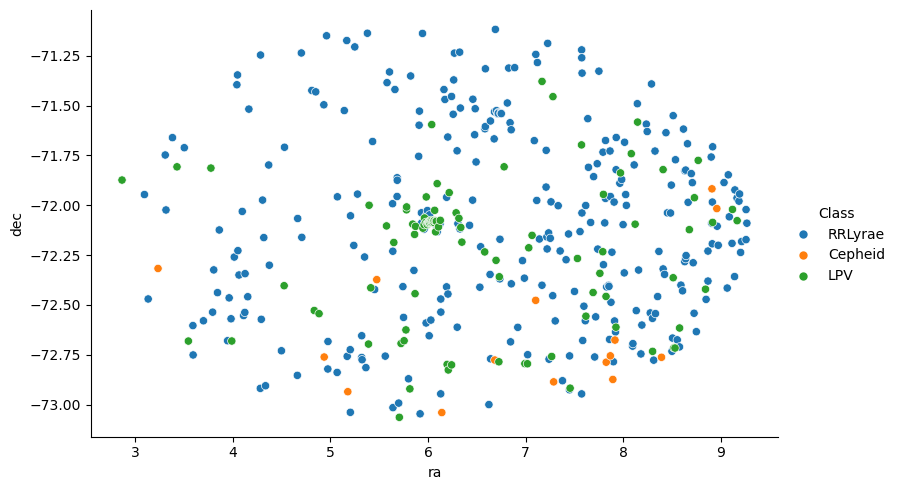

In [30]:
sns.relplot(data=tuc_47_stars, x='ra', y='dec', hue='Class', aspect=1.61)
plt.show()

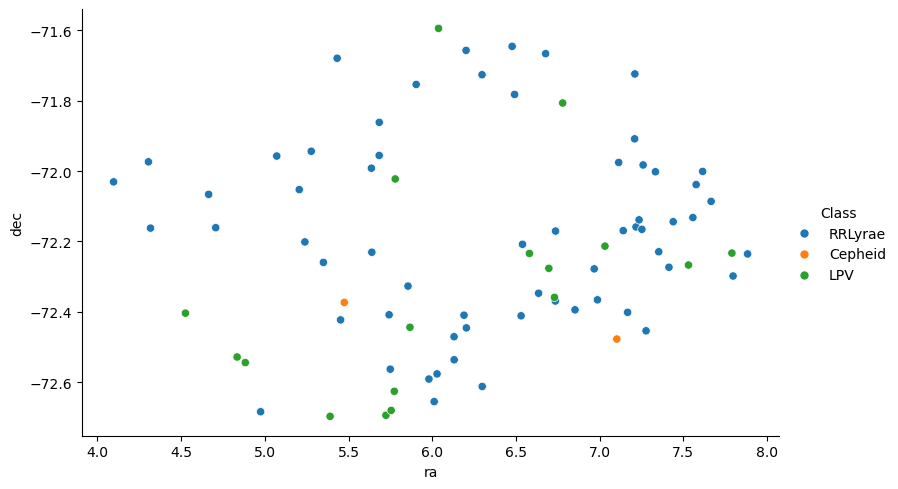

In [31]:
# now compare to the ones after matching
df = labeled_table[labeled_table['Region'] == '47']

sns.relplot(data=df, x='ra', y='dec', hue='Class', aspect=1.61)
plt.show()

Based off these plots, we can infer that:
1. Many stars that were located in the original dataset were inside or very near the globular cluster which DP1 couldn't capture very well
2. The coordinates of the original space is a lot larger than the region dp1 captured

In [54]:
# save to csv
labeled_table.to_csv('international_catalog.csv', index=False)